In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/cleaned_data.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


### dataset overview

In [6]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (779425, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  object 
 2   Description  779425 non-null  object 
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  object 
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  float64
 7   Country      779425 non-null  object 
 8   Sales        779425 non-null  float64
 9   Year         779425 non-null  int64  
 10  Month        779425 non-null  int64  
 11  Day          779425 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 71.4+ MB


### Create Customer-Product Matrix

In [7]:
customer_product_matrix = pd.pivot_table(
    df,
    index="Customer ID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

customer_product_matrix.head()

Description,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### matrix shape

In [8]:
print("Rows (Customers):", customer_product_matrix.shape[0])
print("Columns (Products):", customer_product_matrix.shape[1])

Rows (Customers): 5878
Columns (Products): 5283


### Calculate Customer Similarity

In [9]:
customer_similarity = cosine_similarity(
    customer_product_matrix
)
customer_similarity.shape

(5878, 5878)

In [10]:
similarity_df = pd.DataFrame( #(smiliar data frame)
    customer_similarity,
    index=customer_product_matrix.index,
    columns=customer_product_matrix.index
)

similarity_df.head()

Customer ID,12346.0,12347.0,12348.0,12349.0,12350.0,12351.0,12352.0,12353.0,12354.0,12355.0,...,18278.0,18279.0,18280.0,18281.0,18282.0,18283.0,18284.0,18285.0,18286.0,18287.0
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,1.000000,0.000000,0.000000,0.000002,0.000000,0.000000,2.554410e-07,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,8.762815e-07,0.000000
12347.0,0.000000,1.000000,0.162033,0.012087,0.013398,0.042812,2.250879e-02,0.021666,0.021202,0.408637,...,0.014974,0.0,0.017170,0.031768,0.012001,0.097815,0.029073,0.0,3.445478e-02,0.069793
12348.0,0.000000,0.162033,1.000000,0.000246,0.000316,0.000000,1.066435e-03,0.000000,0.012006,0.213272,...,0.000000,0.0,0.000000,0.000000,0.000000,0.159949,0.000000,0.0,0.000000e+00,0.063602
12349.0,0.000002,0.012087,0.000246,1.000000,0.029190,0.012112,1.198888e-01,0.206341,0.004445,0.021971,...,0.017490,0.0,0.001322,0.004706,0.006470,0.088282,0.052627,0.0,4.897702e-02,0.038543
12350.0,0.000000,0.013398,0.000316,0.029190,1.000000,0.000000,1.305029e-03,0.060057,0.000000,0.000000,...,0.000000,0.0,0.000000,0.072598,0.000000,0.023528,0.000000,0.0,3.069845e-02,0.000000


### Product Recommendation Function

In [11]:
def recommend_products(customer_id, top_n=5):
    similar_customers = similarity_df[customer_id].sort_values(
        ascending=False
    )[1:6]
    recommended_products = customer_product_matrix.loc[
        similar_customers.index
    ].sum()
    recommendations = recommended_products.sort_values(
        ascending=False
    )
    return recommendations.head(top_n)

### Test Recommendations

In [13]:
print(type(sample_customer))

print(similarity_df.index.dtype)
print(similarity_df.columns.dtype)

<class 'numpy.float64'>
float64
float64


In [14]:
sample_customer = customer_product_matrix.index[0]
print("Customer:", sample_customer)
print(sample_customer in similarity_df.index)
print(sample_customer in similarity_df.columns)

Customer: 12346.0
True
True


### Product Recommendation Function

In [16]:
similarity_df = pd.DataFrame(
    customer_similarity,
    index=customer_product_matrix.index.tolist(),
    columns=customer_product_matrix.index.tolist()
)

In [18]:
def recommend_products(customer_id, top_n=5):
    similar_customers = similarity_df[customer_id]\
        .sort_values(ascending=False)

    similar_customers = similar_customers.iloc[1:6]

    recommended_products = customer_product_matrix.loc[
        similar_customers.index
    ].sum()

    recommendations = recommended_products.sort_values(
        ascending=False
    )

    return recommendations.head(top_n)

### Test Recommendations

In [19]:
sample_customer = customer_product_matrix.index[0]
print("Customer ID:", sample_customer)
recommend_products(sample_customer)

Customer ID: 12346.0


Description
MEDIUM CERAMIC TOP STORAGE JAR         170
WOODEN HEART CHRISTMAS SCANDINAVIAN     48
BLUE PUDDING SPOON                      48
RED PUDDING SPOON                       48
LARGE CHINESE STYLE SCISSOR             40
dtype: int64

In [17]:
sample_customer = customer_product_matrix.index[0]
similarity_df[sample_customer].head()

12346.0    1.000000
12347.0    0.000000
12348.0    0.000000
12349.0    0.000002
12350.0    0.000000
Name: 12346.0, dtype: float64

### Top Selling Products

In [21]:
top_products = df.groupby(
    "Description"
)["Quantity"].sum().sort_values(
    ascending=False
).head(10)
top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64

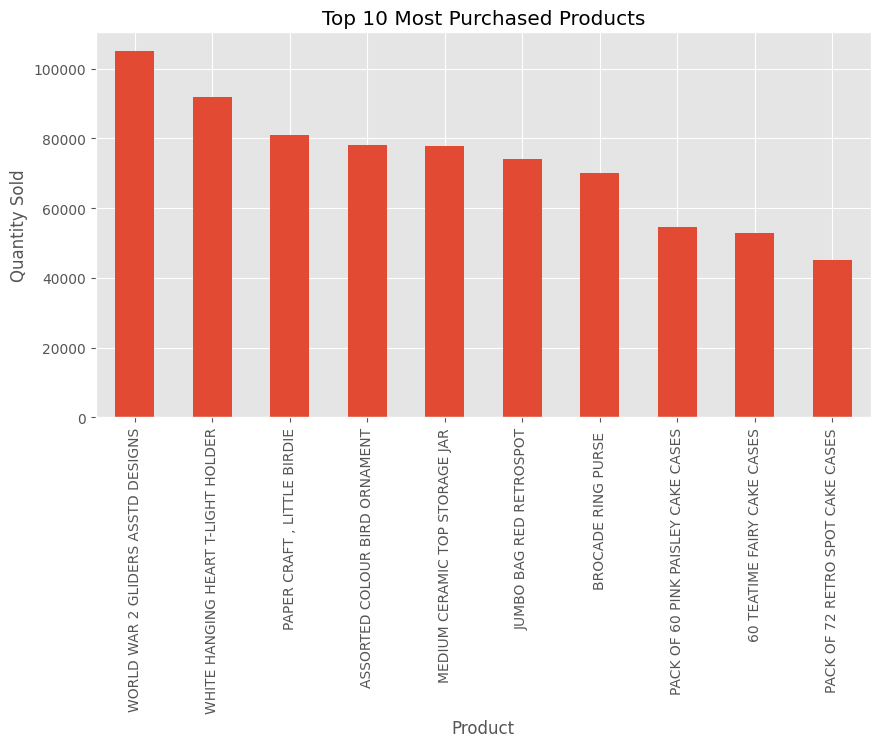

In [22]:
plt.style.use("ggplot")
plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.show()